
# Time-Series Forecasting with Volatility Regimes — RNN (LSTM) vs Transformer

**Goal.** Predict a noisy sinusoid with **regime-switching volatility** using two architectures:
- **RNN (LSTM)** forecasting the next value;
- **Transformer Encoder** (causal) forecasting the next value.

Both models predict a **Gaussian conditional distribution** (mean and variance) so we can compare:
- **MSE** (on means),
- **Gaussian Negative Log-Likelihood (NLL)**,
- **Calibration** (empirical coverage vs nominal).



## 1) Environment


In [1]:

import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.stats import norm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(42)
torch.manual_seed(42)



## 2) Synthetic Data Generator — Sinusoid with Volatility Regimes
- Signal: \( y_t = A \sin(2\pi f t + \phi) + \epsilon_t \)
- Volatility regimes: piecewise-constant noise std \(\sigma_t \in \{\sigma_1, \sigma_2, ...\}\)
- Optionally, we include **regime index** as an input feature (exogenous control). For the base comparison we won't use it.


In [2]:

def make_vol_regime_sigma(T, segment_lengths=(200, 200, 200, 200), sigmas=(0.1, 0.4, 0.2, 0.6)):
    """Create a piecewise-constant sigma_t array of length T."""
    sigma = np.zeros(T, dtype=np.float32)
    idx = 0
    for L, s in zip(segment_lengths, sigmas):
        end = min(idx + L, T)
        sigma[idx:end] = s
        idx = end
        if idx >= T:
            break
    if idx < T:
        sigma[idx:] = sigmas[-1]
    # Also return regime ids (0..k-1)
    regime = np.zeros(T, dtype=np.int64)
    idx = 0
    for rid, (L, s) in enumerate(zip(segment_lengths, sigmas)):
        end = min(idx + L, T)
        regime[idx:end] = rid
        idx = end
        if idx >= T:
            break
    if idx < T:
        regime[idx:] = len(sigmas) - 1
    return sigma, regime

def make_sinus_series(T=1000, A=1.0, f=1/50.0, phi=0.0, segment_lengths=(250,250,250,250),
                      sigmas=(0.1, 0.4, 0.2, 0.5), seed=0):
    rng = np.random.default_rng(seed)
    t = np.arange(T, dtype=np.float32)
    base = A * np.sin(2*np.pi*f*t + phi).astype(np.float32)
    sigma_t, regime = make_vol_regime_sigma(T, segment_lengths, sigmas)
    noise = rng.normal(0.0, sigma_t).astype(np.float32)
    y = base + noise
    return y, sigma_t, regime

# quick preview (optional; no plots here to keep output clean)
# y, sig, reg = make_sinus_series(T=1000, seed=1)
# y[:5], sig[:5], reg[:5]



## 3) Sliding-Window Dataset
- Input: last `context` observations of `y` (shape `[context]`).
- Target: next value `y_{t}`.
- We also keep the **true sigma_t** for evaluation/calibration.


In [3]:

class WindowDataset(Dataset):
    def __init__(self, series, sigma, context=64):
        self.series = np.asarray(series, dtype=np.float32)
        self.sigma = np.asarray(sigma, dtype=np.float32)
        self.context = context
        self.N = len(self.series) - context
    def __len__(self):
        return max(0, self.N)
    def __getitem__(self, idx):
        x = self.series[idx:idx+self.context]        # [context]
        y = self.series[idx+self.context]            # scalar target
        s = self.sigma[idx+self.context]             # true sigma at target time
        return torch.from_numpy(x).float(), torch.tensor([y]).float(), torch.tensor([s]).float()



## 4) Models
We predict **mean** and **log-variance** so that we can use Gaussian NLL.  
- **RNN (LSTM)**: single-layer LSTM + linear heads.  
- **Transformer Encoder**: sinusoidal positional encoding + causal mask.


In [4]:

class LSTMGaussian(nn.Module):
    def __init__(self, input_dim=1, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 2)  # mean, log_var
    def forward(self, x):
        # x: [B, T] -> [B, T, 1]
        x = x.unsqueeze(-1)
        h, _ = self.lstm(x)
        last = h[:, -1, :]
        out = self.head(last)
        mean, log_var = out[:, :1], out[:, 1:2]
        return mean, log_var

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]
    def forward(self, x):
        # x: [B, T, d_model]
        T = x.size(1)
        return x + self.pe[:, :T, :]

class TransformerGaussian(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, dim_ff=128):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_ff, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pos = PositionalEncoding(d_model)
        self.head = nn.Linear(d_model, 2)
    def forward(self, x):
        # x: [B, T] -> [B, T, 1]
        x = x.unsqueeze(-1)
        z = self.input_proj(x)
        z = self.pos(z)
        # causal mask (no future info)
        T = z.size(1)
        mask = torch.triu(torch.ones(T, T, device=z.device)*float('-inf'), diagonal=1)
        h = self.encoder(z, mask)
        last = h[:, -1, :]
        out = self.head(last)
        mean, log_var = out[:, :1], out[:, 1:2]
        return mean, log_var



## 5) Losses & Metrics
- **Gaussian NLL:** \(0.5\,(\log \sigma^2 + (y-\mu)^2/\sigma^2) + 0.5\log(2\pi)\)
- **MSE:** \((y-\mu)^2\)
- **Calibration:** empirical coverage of prediction intervals vs nominal levels.


In [5]:

def gaussian_nll(y, mean, log_var):
    # y, mean, log_var: [B,1]
    return 0.5*(log_var + (y-mean)**2 / torch.exp(log_var) + math.log(2*math.pi))

def evaluate_metrics(model, loader):
    model.eval()
    mses, nlls = [], []
    ys_all, means_all, sigmas_pred_all = [], [], []
    with torch.no_grad():
        for x, y, _sig_true in loader:
            x = x.to(device)
            y = y.to(device)
            mean, log_var = model(x)
            nll = gaussian_nll(y, mean, log_var)
            mse = (y - mean)**2
            mses.append(mse.cpu().numpy())
            nlls.append(nll.cpu().numpy())
            ys_all.append(y.cpu().numpy())
            means_all.append(mean.cpu().numpy())
            sigmas_pred_all.append(np.exp(log_var.cpu().numpy()/2))
    mses = np.concatenate(mses, axis=0)
    nlls = np.concatenate(nlls, axis=0)
    ys = np.concatenate(ys_all, axis=0)
    means = np.concatenate(means_all, axis=0)
    sigmas = np.concatenate(sigmas_pred_all, axis=0)
    return float(mses.mean()), float(nlls.mean()), ys, means, sigmas

def calibration_coverage(ys, means, sigmas, levels=(0.5, 0.68, 0.8, 0.9, 0.95)):
    # Assuming Gaussian predictive: coverage for symmetric intervals
    z = np.abs((ys - means) / (sigmas + 1e-8))
    # For a Normal(0,1), coverage c corresponds to threshold z_c such that P(|Z|<=z_c)=c
    from scipy.stats import norm
    nominal = []
    empirical = []
    for c in levels:
        thr = norm.ppf((1+c)/2.0)
        covered = (z <= thr).mean()
        nominal.append(c)
        empirical.append(float(covered))
    return np.array(nominal), np.array(empirical)



## 6) Training Utilities
Simple training loops with Adam and gradient clipping.


In [6]:

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, clip=1.0, verbose=True):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    best_val = float('inf')
    history = {'train_nll':[], 'val_nll':[]}
    for ep in range(1, epochs+1):
        model.train()
        tr_loss = 0.0; n_tr = 0
        for x, y, _ in train_loader:
            x, y = x.to(device), y.to(device)
            mean, log_var = model(x)
            loss = gaussian_nll(y, mean, log_var).mean()
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            tr_loss += loss.item() * x.size(0); n_tr += x.size(0)
        tr_loss /= max(1, n_tr)
        # val
        model.eval()
        va_loss = 0.0; n_va = 0
        with torch.no_grad():
            for x, y, _ in val_loader:
                x, y = x.to(device), y.to(device)
                mean, log_var = model(x)
                loss = gaussian_nll(y, mean, log_var).mean()
                va_loss += loss.item() * x.size(0); n_va += x.size(0)
        va_loss /= max(1, n_va)
        history['train_nll'].append(tr_loss); history['val_nll'].append(va_loss)
        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"Epoch {ep:03d} | train NLL={tr_loss:.4f} | val NLL={va_loss:.4f}")
        if va_loss < best_val:
            best_val = va_loss
            best_state = {k:v.cpu().detach().clone() for k,v in model.state_dict().items()}
    # load best
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return history



## 7) Data Preparation (Train/Val/Test) and Dataloaders


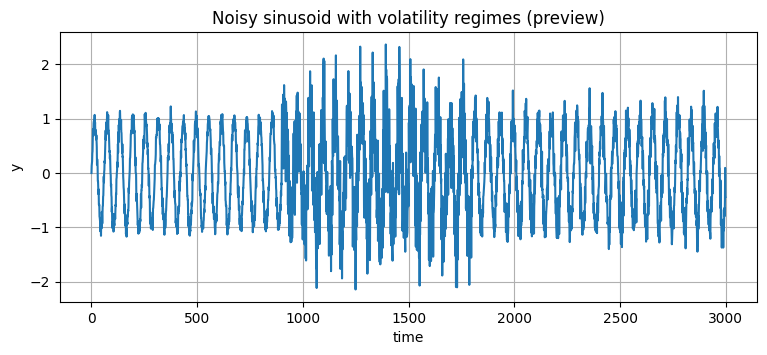

In [7]:

# Generate a long series then split into train/val/test contiguous blocks
T_total = 3000
y, sigma_t, regime = make_sinus_series(T=T_total, f=1/60.0, segment_lengths=(900, 900, 1200), sigmas=(0.1, 0.5, 0.2), seed=7)

context = 64
train_end = 2000
val_end = 2500

train_ds = WindowDataset(y[:train_end], sigma_t[:train_end], context=context)
val_ds   = WindowDataset(y[train_end-context:val_end], sigma_t[train_end-context:val_end], context=context)
test_ds  = WindowDataset(y[val_end-context:], sigma_t[val_end-context:], context=context)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

# Visualize the raw series
plt.figure(figsize=(9,3.5))
plt.plot(y)
plt.title("Noisy sinusoid with volatility regimes (preview)")
plt.xlabel("time"); plt.ylabel("y"); plt.grid(True)
plt.show()



## 8) Train RNN (LSTM) Model


Epoch 001 | train NLL=1.2124 | val NLL=1.0632
Epoch 005 | train NLL=0.4991 | val NLL=0.1572
Epoch 010 | train NLL=0.4437 | val NLL=0.1207
Epoch 015 | train NLL=0.4384 | val NLL=0.1411
Epoch 020 | train NLL=0.4270 | val NLL=0.1180
Epoch 025 | train NLL=0.4207 | val NLL=0.0856


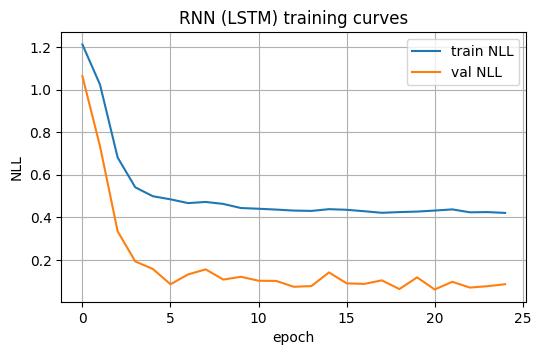

RNN — Test MSE: 0.0486 | Test NLL: 0.0773


In [8]:

rnn = LSTMGaussian(input_dim=1, hidden=64)
hist_rnn = train_model(rnn, train_loader, val_loader, epochs=25, lr=1e-3, clip=1.0, verbose=True)

plt.figure(figsize=(6,3.5))
plt.plot(hist_rnn['train_nll'], label="train NLL")
plt.plot(hist_rnn['val_nll'], label="val NLL")
plt.title("RNN (LSTM) training curves")
plt.xlabel("epoch"); plt.ylabel("NLL"); plt.grid(True); plt.legend()
plt.show()

mse_rnn, nll_rnn, ys_rnn, means_rnn, sigmas_rnn = evaluate_metrics(rnn, test_loader)
print(f"RNN — Test MSE: {mse_rnn:.4f} | Test NLL: {nll_rnn:.4f}")



## 9) Train Transformer Model


Epoch 001 | train NLL=1.0539 | val NLL=0.1385
Epoch 005 | train NLL=0.4603 | val NLL=0.1549
Epoch 010 | train NLL=0.2195 | val NLL=-0.0096
Epoch 015 | train NLL=0.1381 | val NLL=0.0453
Epoch 020 | train NLL=0.1273 | val NLL=-0.0109
Epoch 025 | train NLL=0.1200 | val NLL=-0.0212


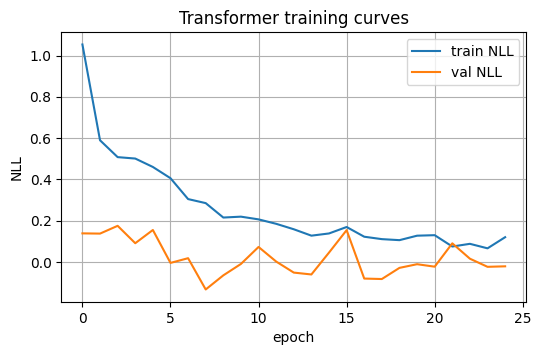

Transformer — Test MSE: 0.0453 | Test NLL: -0.1170


In [9]:

transf = TransformerGaussian(d_model=64, nhead=4, num_layers=2, dim_ff=128)
hist_tr = train_model(transf, train_loader, val_loader, epochs=25, lr=1e-3, clip=1.0, verbose=True)

plt.figure(figsize=(6,3.5))
plt.plot(hist_tr['train_nll'], label="train NLL")
plt.plot(hist_tr['val_nll'], label="val NLL")
plt.title("Transformer training curves")
plt.xlabel("epoch"); plt.ylabel("NLL"); plt.grid(True); plt.legend()
plt.show()

mse_tr, nll_tr, ys_tr, means_tr, sigmas_tr = evaluate_metrics(transf, test_loader)
print(f"Transformer — Test MSE: {mse_tr:.4f} | Test NLL: {nll_tr:.4f}")



## 10) Calibration — Coverage vs Nominal (Gaussian Intervals)
We compute empirical coverage for nominal levels (50%, 68%, 80%, 90%, 95%).  
Closer to the diagonal = better calibration.


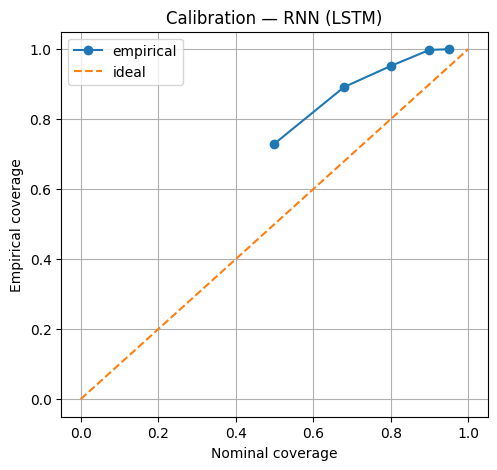

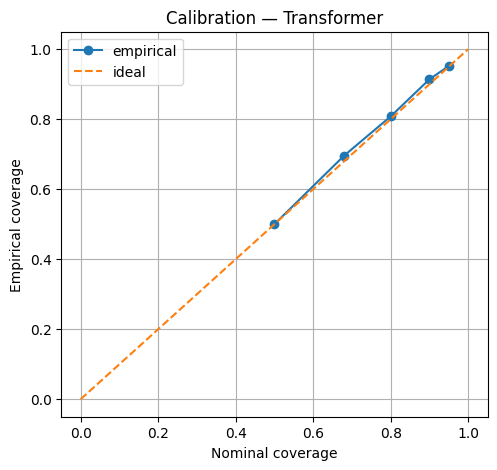

In [10]:
def plot_calibration(nominal, empirical, title):
    plt.figure(figsize=(5.5,5.0))
    plt.plot(nominal, empirical, marker='o', label="empirical")
    plt.plot([0,1],[0,1], linestyle='--', label="ideal")
    plt.title(title); plt.xlabel("Nominal coverage"); plt.ylabel("Empirical coverage"); plt.grid(True); plt.legend()
    plt.show()

levels = (0.5, 0.68, 0.8, 0.9, 0.95)

nom_rnn, emp_rnn = calibration_coverage(ys_rnn, means_rnn, sigmas_rnn, levels=levels)
plot_calibration(nom_rnn, emp_rnn, "Calibration — RNN (LSTM)")

nom_tr, emp_tr = calibration_coverage(ys_tr, means_tr, sigmas_tr, levels=levels)
plot_calibration(nom_tr, emp_tr, "Calibration — Transformer")



## 11) Visual Forecast Example (Test Split)
We overlay predictions and ±1 standard deviation bands.


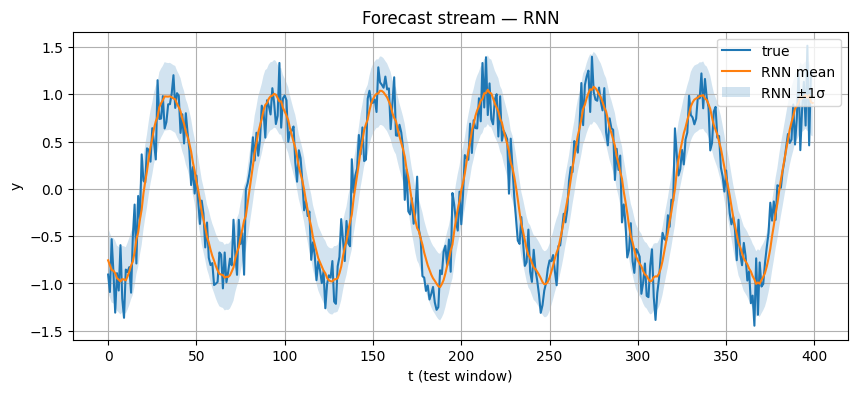

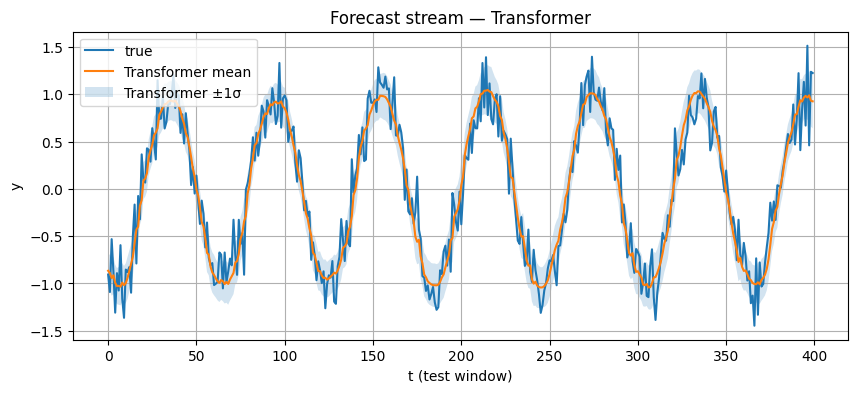

In [11]:

# Build a contiguous test forecast stream using the trained models
def roll_forecast(model, series, start, length, context):
    model.eval()
    ys = []
    mus = []
    sigs = []
    with torch.no_grad():
        for t in range(start, start+length):
            x = torch.from_numpy(series[t-context:t]).float().unsqueeze(0).to(device)
            mean, log_var = model(x)
            ys.append(series[t])
            mus.append(mean.cpu().numpy().reshape(-1)[0])
            sigs.append(float(np.exp(log_var.cpu().numpy().reshape(-1)[0]/2)))
    return np.array(ys), np.array(mus), np.array(sigs)

test_start = val_end  # first index of test region
length = 400
ys_stream, mu_rnn, sg_rnn = roll_forecast(rnn, y, test_start, length, context)
_, mu_tr, sg_tr = roll_forecast(transf, y, test_start, length, context)

plt.figure(figsize=(10,4))
plt.plot(ys_stream, label="true")
plt.plot(mu_rnn, label="RNN mean")
plt.fill_between(np.arange(length), mu_rnn - sg_rnn, mu_rnn + sg_rnn, alpha=0.2, label="RNN ±1σ")
plt.title("Forecast stream — RNN")
plt.xlabel("t (test window)"); plt.ylabel("y"); plt.grid(True); plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(ys_stream, label="true")
plt.plot(mu_tr, label="Transformer mean")
plt.fill_between(np.arange(length), mu_tr - sg_tr, mu_tr + sg_tr, alpha=0.2, label="Transformer ±1σ")
plt.title("Forecast stream — Transformer")
plt.xlabel("t (test window)"); plt.ylabel("y"); plt.grid(True); plt.legend()
plt.show()
